In [1]:
# importing libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

#libraries for preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [2]:
# load data
df = pd.read_csv('C:/Users/sarth/sml_project/artifacts/train_data.csv')
df.head()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group D,master's degree,standard,none,62,70,75
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83
2,female,group D,some college,free/reduced,none,79,89,86
3,male,group C,master's degree,free/reduced,none,61,67,66
4,male,group E,high school,standard,none,73,64,57


In [3]:
# Shape of the data
df.shape

(800, 8)

In [4]:
# Checking for null values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
# Description of the data
df.describe()

,math score,reading score,writing score
count,800.000000,800.000000,800.000000
mean,66.496250,69.555000,68.456250
std,15.024302,14.461532,15.085342
min,8.000000,24.000000,15.000000
25%,57.000000,60.000000,58.000000
50%,66.000000,70.000000,69.000000
75%,77.000000,80.000000,79.000000
max,100.000000,100.000000,100.000000


In [6]:
# info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       800 non-null    object
 1   race/ethnicity               800 non-null    object
 2   parental level of education  800 non-null    object
 3   lunch                        800 non-null    object
 4   test preparation course      800 non-null    object
 5   math score                   800 non-null    int64 
 6   reading score                800 non-null    int64 
 7   writing score                800 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 50.1+ KB


In [7]:
#checking for duplicates
df.duplicated().sum()

0

<AxesSubplot:>

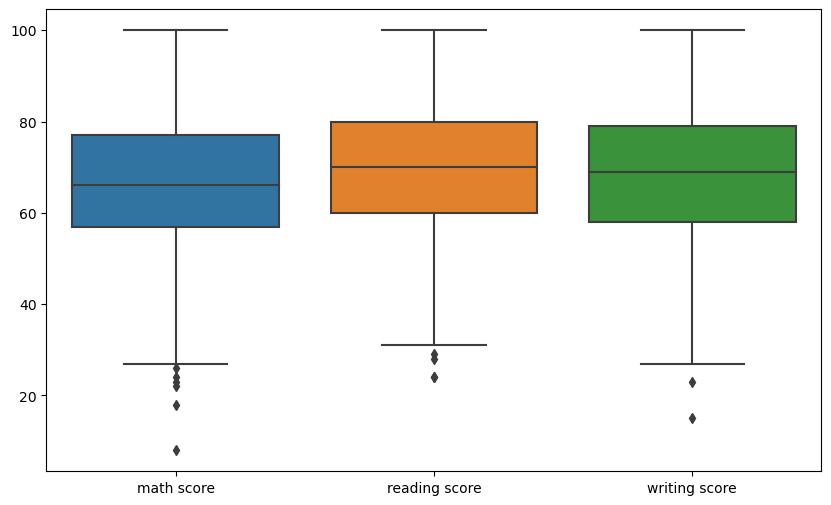

In [8]:
# checking for outliers using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df)

In [9]:
df['Overall_Score'] = df['math score'] + df['reading score'] + df['writing score']
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Overall_Score
0,female,group D,master's degree,standard,none,62,70,75,207
1,female,group C,bachelor's degree,free/reduced,completed,66,83,83,232
2,female,group D,some college,free/reduced,none,79,89,86,254
3,male,group C,master's degree,free/reduced,none,61,67,66,194
4,male,group E,high school,standard,none,73,64,57,194


In [10]:
df['gender'].value_counts()

female    421
male      379
Name: gender, dtype: int64

In [11]:
df['race/ethnicity'].value_counts()

group C    260
group D    202
group B    153
group E    116
group A     69
Name: race/ethnicity, dtype: int64

In [12]:
# one hot encoding helps to encode categorical variables into numerical format. We will use one hot encoding for the categorical variables in our dataset.
cat_one = ['gender', 'lunch', 'test preparation course']
ohe =  OneHotEncoder(sparse=False, drop='first')
for i in cat_one:
    transformed = ohe.fit_transform(df[[i]])
    df[i] = ohe.fit_transform(df[[i]])

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Overall_Score
0,0.0,group D,master's degree,1.0,1.0,62,70,75,207
1,0.0,group C,bachelor's degree,0.0,0.0,66,83,83,232
2,0.0,group D,some college,0.0,1.0,79,89,86,254
3,1.0,group C,master's degree,0.0,1.0,61,67,66,194
4,1.0,group E,high school,1.0,1.0,73,64,57,194


In [14]:
# label encoding helps to encode categorical variables into numerical format. We will use label encoding for the categorical variable '
cat_label = ['race/ethnicity', 'parental level of education']
label_encoder = LabelEncoder()
for i in cat_label:
    df[i] = label_encoder.fit_transform(df[i])

In [15]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Overall_Score
0,0.0,3,3,1.0,1.0,62,70,75,207
1,0.0,2,1,0.0,0.0,66,83,83,232
2,0.0,3,4,0.0,1.0,79,89,86,254
3,1.0,2,3,0.0,1.0,61,67,66,194
4,1.0,4,2,1.0,1.0,73,64,57,194


In [16]:
# seperating features and target variable
X = df.drop(columns=['Overall_Score'])
y = df['Overall_Score']

In [17]:
# Normalization  
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [19]:
# Model training
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
print('Mean Squared Error Test:', mse_test)
print('R2 Score Test:', r2_test)
print('Accuracy Test:', model.score(X_test, y_test))

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
print('Mean Squared Error Train:', mse_train)
print('R2 Score Train:', r2_train)
print('Accuracy Train:', model.score(X_train, y_train))


Mean Squared Error Test: 26.025
R2 Score Test: 0.9857436779457818
Accuracy Test: 0.9857436779457818
Mean Squared Error Train: 0.0
R2 Score Train: 1.0
Accuracy Train: 1.0


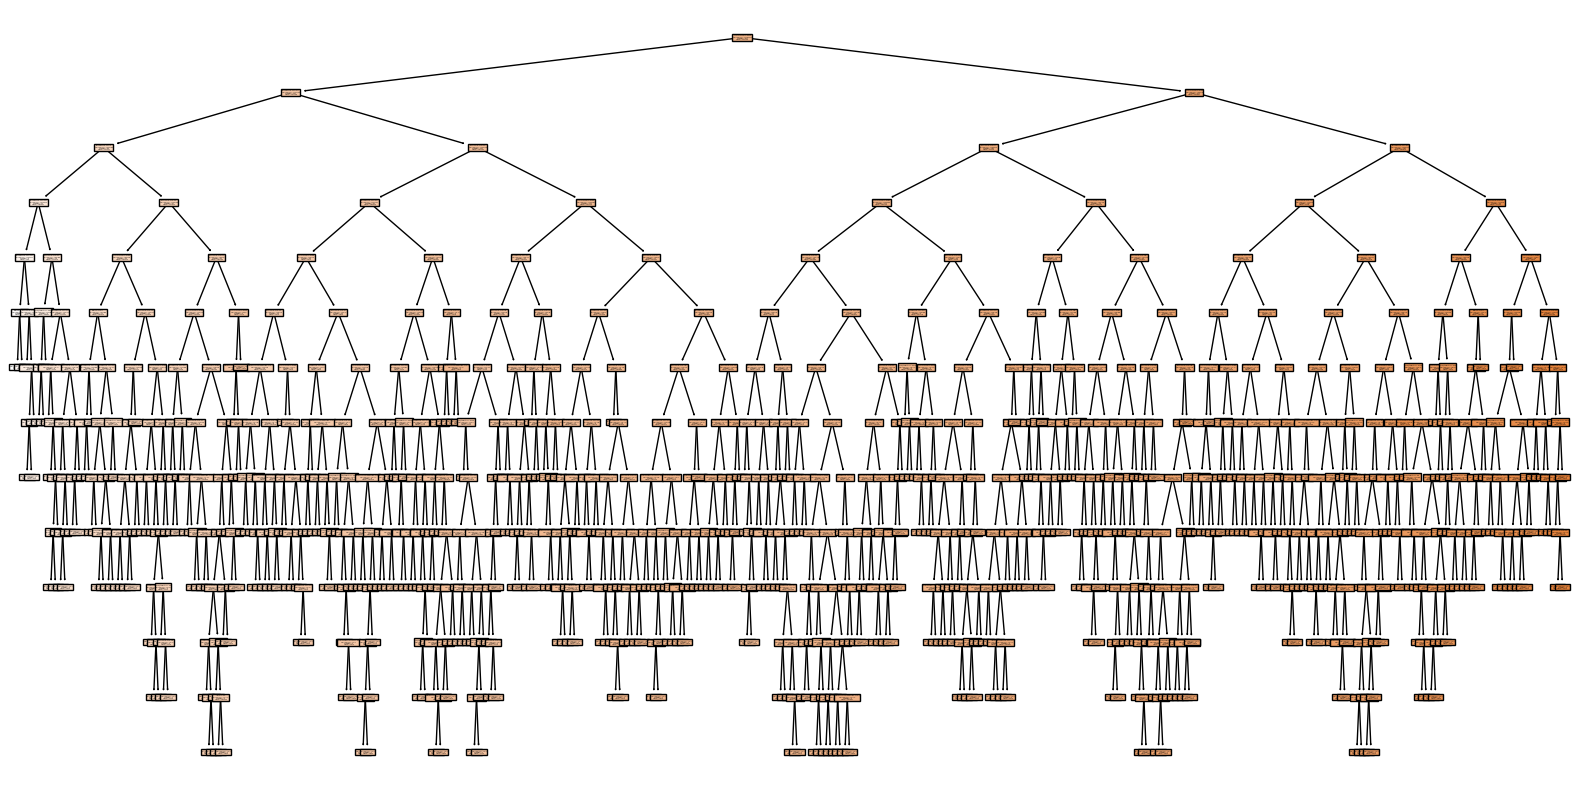

In [20]:

from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(model, feature_names=X.columns, filled=True)
plt.show()

In [21]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'ccp_alpha': [0.01, 0.1, 1, 10, 100],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dtree = DecisionTreeRegressor()
grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_dtree = grid_search.best_estimator_
y_pred_test = best_dtree.predict(X_test)
y_pred_train = best_dtree.predict(X_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
print('Mean Squared Error Test:', mse_test)
print('R2 Score Test:', r2_test)
print('Accuracy Test:', best_dtree.score(X_test, y_test))
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
print('Mean Squared Error Train:', mse_train)
print('R2 Score Train:', r2_train)
print('Accuracy Train:', best_dtree.score(X_train, y_train))

Best Hyperparameters: {'ccp_alpha': 0.01, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mean Squared Error Test: 19.94077422682036
R2 Score Test: 0.9890765763923917
Accuracy Test: 0.9890765763923917
Mean Squared Error Train: 0.7848350694444445
R2 Score Train: 0.9995601876791501
Accuracy Train: 0.9995601876791501


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
param_dist = {
    'ccp_alpha': randint(0, 100),
    'max_depth': randint(1, 50),
    'min_samples_split':randint(2, 20),
    'min_samples_leaf': randint(1, 20)
}
dtree = DecisionTreeRegressor()
random_search = RandomizedSearchCV(estimator=dtree, param_distributions=param_dist, n_iter=10, cv=5, random_state=42)
random_search.fit(X_train, y_train)
print("Best Hyperparameters:", random_search.best_params_)
best_dtree_random = random_search.best_estimator_
y_pred_test_random = best_dtree_random.predict(X_test)
y_pred_train_random = best_dtree_random.predict(X_train)    
mse_test_random = mean_squared_error(y_test, y_pred_test_random)
r2_test_random = r2_score(y_test, y_pred_test_random)
print('Mean Squared Error Test:', mse_test_random)
print('R2 Score Test:', r2_test_random)
print('Accuracy Test:', best_dtree_random.score(X_test, y_test))
mse_train_random = mean_squared_error(y_train, y_pred_train_random)
r2_train_random = r2_score(y_train, y_pred_train_random)
print('Mean Squared Error Train:', mse_train_random)
print('R2 Score Train:', r2_train_random)
print('Accuracy Train:', best_dtree_random.score(X_train, y_train))


Best Hyperparameters: {'ccp_alpha': 20, 'max_depth': 9, 'min_samples_leaf': 7, 'min_samples_split': 19}
Mean Squared Error Test: 142.20067499574063
R2 Score Test: 0.9221034152135832
Accuracy Test: 0.9221034152135832
Mean Squared Error Train: 136.19716934662065
R2 Score Train: 0.9236767118651785
Accuracy Train: 0.9236767118651785


In [23]:
# Best Hyperparameters: {'ccp_alpha': 0.01, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}
dtree_final = DecisionTreeRegressor(ccp_alpha=0.01, max_depth=20, min_samples_leaf=1, min_samples_split=2)
dtree_final.fit(X_train, y_train)
y_pred_test_final = dtree_final.predict(X_test)
y_pred_train_final = dtree_final.predict(X_train)
mse_test_final = mean_squared_error(y_test, y_pred_test_final)
r2_test_final = r2_score(y_test, y_pred_test_final)
print('Mean Squared Error Test:', mse_test_final)
print('R2 Score Test:', r2_test_final)
print('Accuracy Test:', dtree_final.score(X_test, y_test))
mse_train_final = mean_squared_error(y_train, y_pred_train_final)
r2_train_final = r2_score(y_train, y_pred_train_final)
print('Mean Squared Error Train:', mse_train_final)
print('R2 Score Train:', r2_train_final)
print('Accuracy Train:', dtree_final.score(X_train, y_train))


Mean Squared Error Test: 26.224628393487023
R2 Score Test: 0.9856343228384343
Accuracy Test: 0.9856343228384343
Mean Squared Error Train: 0.7848350694444445
R2 Score Train: 0.9995601876791501
Accuracy Train: 0.9995601876791501
